In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value

polygon_gdf['Потенциал развития жилой застройки'] = 4
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории,Потенциал развития жилой застройки
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,3.0,1.0,4.0,3.0,3.0,4.0,4.0,6324.0,2.284321e+09,4


In [3]:
from typing import Final
import geopandas as gpd

LAND_USE_TO_POTENTIAL_COLUMN: Final[dict[str, str]] = {
    "residential": "Потенциал развития жилой застройки",
    "business":     "Потенциал развития застройки общественно-деловой зоны",
    "recreation":   "Потенциал развития застройки рекреационной зоны",
    "special":      "Потенциал развития застройки зоны специального назначения",
    "industrial":   "Потенциал развития застройки промышленной зоны",
    "agriculture":  "Потенциал развития застройки сельскохозяйственной зоны",
    "transport":    "Потенциал развития застройки транспортной зоны",
}

records = []
for _, row in polygon_gdf.iterrows():
    for ip_type, col_name in LAND_USE_TO_POTENTIAL_COLUMN.items():
        records.append({
            "ip_type":  ip_type,
            "ip_value": row[col_name],
            "geometry": row.geometry
        })

# Создаём новый GeoDataFrame
base_gdf = gpd.GeoDataFrame(records, crs=polygon_gdf.crs)
base_gdf = base_gdf.reset_index(drop=True)
base_gdf



,ip_type,ip_value,geometry
0,residential,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
1,business,2.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
2,recreation,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
3,special,3.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
4,industrial,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
5,agriculture,3.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."
6,transport,4.0,"POLYGON ((387861.999 6644712.938, 388202.551 6..."


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,geometry
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,AGRICULTURE,0.918180,"POLYGON ((388511.373 6644951.946, 388558.037 6..."
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,BUSINESS,0.938081,"POLYGON ((388558.037 6645102.374, 388511.373 6..."
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,TRANSPORT,0.891381,"POLYGON ((387957.434 6643444.937, 388007.492 6..."
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,RESIDENTIAL,0.934862,"POLYGON ((388007.492 6643608.409, 387957.434 6..."
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,"POLYGON ((388001.306 6643195.969, 388000.750 6..."


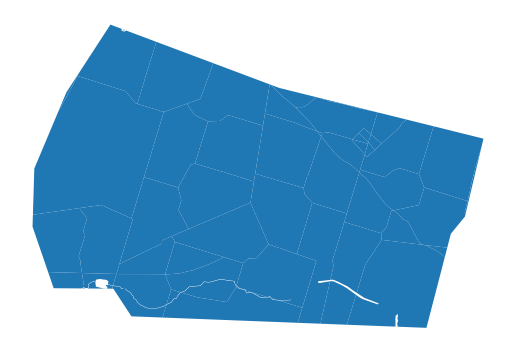

In [4]:
polygon_test = gpd.read_file("/home/mvin/Urbanomy/examples/data/scenario_blocks.geojson")
polygon_test.plot().axis('off')

polygon_test['land_use'] = (
    polygon_test['land_use']
    .astype(str)
    .str.replace(r'^LandUse\.', '', regex=True)
)
polygon_test.head()

In [5]:
import pandas as pd
import geopandas as gpd

USES = ['residential','business','recreation','industrial','transport','special','agriculture']

# 1) подготовим карту оценок из base_gdf: среднее по типу
base_map = (
    base_gdf.assign(ip_type=base_gdf['ip_type'].str.lower())
            .loc[lambda d: d['ip_type'].isin(USES)]
            .groupby('ip_type', as_index=False)['ip_value'].mean()
            .rename(columns={'ip_value': 'ip_value_from_base'})
)

# 2) нормализуем polygon_test и удалим None/NaN типы
polygon_test = polygon_test.copy()
polygon_test['ip_type'] = polygon_test['land_use'].str.lower()
polygon_test = polygon_test[
    polygon_test['ip_type'].notna() & (polygon_test['ip_type'] != 'none')
]

# 3) джоин по типу и возьмем оценку из base_gdf
polygon_test = polygon_test.merge(base_map, on='ip_type', how='left')

# 4) если для типа нет оценки в base_gdf — ставим 0
polygon_test['ip_value'] = polygon_test['ip_value_from_base'].fillna(0)

# 5) оставить только нужные колонки
polygon_test = gpd.GeoDataFrame(
    polygon_test[['ip_type', 'ip_value', 'geometry']].reset_index(drop=True),
    crs=polygon_test.crs
)

polygon_test



,ip_type,ip_value,geometry
0,agriculture,3.0,"POLYGON ((388511.373 6644951.946, 388558.037 6..."
1,business,2.0,"POLYGON ((388558.037 6645102.374, 388511.373 6..."
2,transport,4.0,"POLYGON ((387957.434 6643444.937, 388007.492 6..."
3,residential,4.0,"POLYGON ((388007.492 6643608.409, 387957.434 6..."
4,residential,4.0,"POLYGON ((388000.750 6643199.606, 388001.306 6..."
...,...,...,...
62,business,2.0,"POLYGON ((390950.379 6643779.960, 390941.389 6..."
63,agriculture,3.0,"POLYGON ((391069.678 6644283.933, 391072.529 6..."
64,transport,4.0,"POLYGON ((388222.552 6643218.262, 388215.418 6..."
65,business,2.0,"POLYGON ((388314.421 6645193.770, 388311.871 6..."


In [8]:
polygon_test.explore()

In [7]:
# ID с нуля
polygon_test = polygon_test.reset_index(drop=True)
polygon_test['id'] = polygon_test.index.astype('int64')



In [9]:

# строка с id == 4
row_id4 = polygon_test.loc[polygon_test['id'] == 14]

In [20]:
benchmarks_demo = {
    "residential": {
        "density": 0.25,
        # "built_area": 110468,
        "land_cost": 1500,
        "cost_build": 45_000,
        "price_sale": 90_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,
    },
    "residential_individual": {
        "density": 0.25,
        # "built_area": 110468,
        "land_cost": 1500,
        "cost_build": 48_000,
        "price_sale": 92_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,
    },
    "residential_lowrise": {
        "density": 0.5,
        # "built_area": 294685,
        "land_cost": 1800,
        "cost_build": 50_000,
        "price_sale": 95_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 900,
    },
    "residential_midrise": {
        "density": 1.5,
        # "built_area": 277019,
        "land_cost": 2500,
        "cost_build": 55_000,
        "price_sale": 105_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 1200,
    },
    "residential_multistorey": {
        "density": 3.0,
        # "built_area": 686840,
        "land_cost": 3000,
        "cost_build": 62_000,
        "price_sale": 120_000,
        "construction_years": 4,
        "sale_years": 5,
        "opex_rate": 1500,
    },
    "business": {
        "density": 2.0,
        # "built_area": 1375709,
        "land_cost": 2800,
        "cost_build": 55_000,
        "rent_annual": 14_000,
        "rent_years": 12,
        "occupancy": 0.85,
        "construction_years": 3,
        "opex_rate": 1300,
    },
    "recreation": {
        "density": 0.2,
        # "built_area": 218180,
        "land_cost": 1000,
        "cost_build": 20_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "occupancy": 0.7,
        "construction_years": 2,
        "opex_rate": 1000,
    },
    "special": {
        "density": 1.0,
        # "built_area": 1164399,
        "land_cost": 1200,
        "cost_build": 35_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "occupancy": 0.8,
        "construction_years": 3,
        "opex_rate": 1500,
    },
    "industrial": {
        "density": 1.0,
        # "built_area": 409028,
        "land_cost": 900,
        "cost_build": 38_000,
        "rent_annual": 9_800,
        "rent_years": 12,
        "occupancy": 0.9,
        "construction_years": 2,
        "opex_rate": 700,
    },
    "agriculture": {
        "density": 0.1,
        # "built_area": 40104,
        "land_cost": 300,
        "cost_build": 25_000,
        "rent_annual": 2_500,
        "rent_years": 15,
        "occupancy": 0.95,
        "construction_years": 1,
        "opex_rate": 300,
    },
    "transport": {
        "density": 1.2,
        # "built_area": 709760,
        "land_cost": 1100,
        "cost_build": 18_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "occupancy": 0.88,
        "construction_years": 3,
        "opex_rate": 600,
    },
}



In [17]:
stats = polygon_test['ip_type'].value_counts().reset_index()
stats.columns = ['ip_type', 'count']
stats

,ip_type,count
0,special,20
1,agriculture,17
2,business,9
3,recreation,9
4,residential,8
5,transport,3
6,industrial,1


In [21]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer
# polygon_test
an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
gdf_out, summary = an.calculate_investment_metrics(row_id4)
summary

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

,NPV,IRR,ROI,PP_years,EI,investment_attractiveness,INV
profile,,,,,,,
recreation,-91028406.96,0.1,2.88,None,14.35,4.0,NaN


In [16]:
gdf_out

,geometry,ip_type,ip_value,ECON_NPV,ECON_IRR,ECON_ROI,ECON_PP_years,ECON_EI,INV
14,"POLYGON ((389636.818 6643464.126, 389425.628 6...",recreation,4.0,93012502.53,0.14,3.66,13.46,41.54,NaN
